# Synthetic Ground-Truth Training

Validation experiment: generate a voltage trace from **known** AdEx parameters,
then attempt to recover those parameters via gradient-based training.

This isolates the training pipeline from experimental noise — if training works here,
any failure on real data points to data/model mismatch rather than pipeline bugs.

**Setup:**
- Ground truth parameters: Naud "adaptation" set (configurable)
- Current stimulus: reuses experimental current waveform for realism
- Initial parameters: small perturbation (~15%) from ground truth
- Two-stage training: Stage 1 (Guarino, coarse) → Stage 2 (fine-tune adaptation)

In [1]:
import logging

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from jax import config

from ADoptEX.core.data import TraceData, crop_to_stim_window, detect_spikes, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    GuarinoFeatures,
    GuarinoLossConfig,
    VanRossumLossConfig,
    extract_experimental_features,
    guarino_loss,
    make_guarino_loss_fn,
    make_van_rossum_loss_fn,
    spike_train_from_voltage,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training import TrainingResult
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

SEED = 42

## 1. Ground Truth Parameters & Current Stimulus

Build a synthetic step-current stimulus (independent of experimental sampling),
then define ground truth AdEx parameters. Using a synthetic current lets us
freely adjust `dt_ms` and the stim window without being tied to a recording.

In [2]:
# --- Synthetic step-current waveform ---
# Adjust dt_ms / t_max_ms / stim window freely; no experimental data dependency.
dt_ms = 0.025
t_max_ms = 100.0
stim_delay_ms = 5.0
stim_duration_ms = 95.0
stim_current_pA = 500.0

n_samples = int(round(t_max_ms / dt_ms))
time_arr = np.arange(n_samples) * dt_ms
current_arr = np.zeros(n_samples)
stim_start_idx = int(round(stim_delay_ms / dt_ms))
stim_end_idx = int(round((stim_delay_ms + stim_duration_ms) / dt_ms))
current_arr[stim_start_idx:stim_end_idx] = stim_current_pA

exp_cropped = TraceData(
    time=time_arr,
    voltage=np.zeros(n_samples),  # placeholder; GT voltage is simulated below
    current=current_arr,
    dt_ms=dt_ms,
    spike_times=np.array([]),
    stim_start_idx=stim_start_idx,
    stim_end_idx=stim_end_idx,
    stim_current_pA=float(stim_current_pA),
)

print(f"Current waveform: {exp_cropped.n_samples} samples, dt={exp_cropped.dt_ms:.3f} ms")
print(f"Stim window: idx {exp_cropped.stim_start_idx} - {exp_cropped.stim_end_idx} ({exp_cropped.stim_duration_ms:.1f} ms)")
print(f"Stim current: {exp_cropped.stim_current_pA:.1f} pA")

Current waveform: 4000 samples, dt=0.025 ms
Stim window: idx 200 - 4000 (95.0 ms)
Stim current: 500.0 pA


In [3]:
# --- Ground truth parameters (change this to test different regimes) ---
GROUND_TRUTH_BASE = "tonic"  # "tonic", "adaptation", or "original"

ground_truth_params = dict(NAUD_PARAMETERS[GROUND_TRUTH_BASE])
# ground_truth_params["v_threshold"] = 0.0
# ground_truth_params["delta_T"] = 3.0

# Override values that would sit at parameter bounds (which prevents perturbation
# and makes recovery trivial/impossible). Choose values well inside PARAM_BOUNDS.
# ground_truth_params["v_reset"] = -58.0   # bounds: [-60, -45], midpoint -52.5
# ground_truth_params["E_L"] = -72.0       # bounds: [-75, -68], midpoint -71.5
# ground_truth_params["v_T"] = -45.0       # bounds: [-60, -30], well inside
# ground_truth_params["tau_w"] = 200.0     # bounds: [20, 320], well inside

print(f"Ground truth base: {GROUND_TRUTH_BASE}")
print("Ground truth parameters:")
for k, v in ground_truth_params.items():
    bounds = PARAM_BOUNDS.get(k)
    if bounds:
        pos = (v - bounds.min) / (bounds.max - bounds.min) * 100
        print(f"  {k:<12} {v:>10.3f}  [{bounds.min}, {bounds.max}]  ({pos:.0f}% into range)")
    else:
        print(f"  {k:<12} {v:>10.3f}")

Ground truth base: tonic
Ground truth parameters:
  C_m             200.000  [10.0, 240.0]  (83% into range)
  g_L              10.000  [6.0, 14.0]  (50% into range)
  E_L             -70.000  [-110.0, -65.0]  (89% into range)
  v_T             -50.000  [-60.0, -35.0]  (40% into range)
  delta_T           2.000  [1, 20.0]  (5% into range)
  v_reset         -58.000  [-80.0, -45.0]  (63% into range)
  v_threshold       0.000  [-20.0, 30.0]  (40% into range)
  tau_w            30.000  [20.0, 320.0]  (3% into range)
  a                 2.000  [-5.0, 5.0]  (70% into range)
  b                 0.000  [0.0, 65.0]  (0% into range)
  I               500.000


## 2. Generate Synthetic Voltage Trace

Simulate with ground truth parameters and the experimental current waveform,
then package the result as `TraceData` (same structure as experimental data).

INFO:2026-04-29 14:22:50,222:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Ground truth simulation: 9 spikes, 90.0 Hz

Synthetic TraceData: 4000 samples, 9 spikes
Spike times: [19.3 28.3 37.5 46.8 56.2 65.6 75.2 84.7 94.3] ms
Stim window: idx 200 - 4000 (95.0 ms)


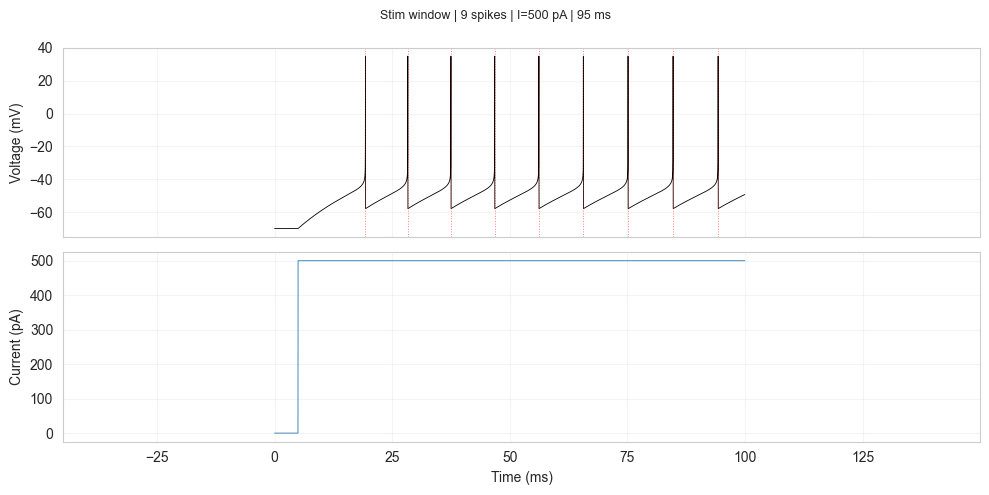

In [4]:
# --- Simulate ground truth ---
# IMPORTANT: use_surrogate=True so the forward pass matches the training cell exactly.
# AdEx uses jax.lax.select (boolean), AdExSurrogate uses arithmetic blend (s*a + (1-s)*b).
# Even though both produce 0/1 spikes, floating-point differences accumulate over 4000
# timesteps and cause a significant loss floor if mismatched.
sim_gt = simulate_with_current_trace(
    params=ground_truth_params,
    current_trace_pA=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms,
    use_surrogate=False,
)

print(f"Ground truth simulation: {sim_gt.n_spikes} spikes, {sim_gt.firing_rate_hz:.1f} Hz")

# --- Package as TraceData (same structure as experimental data) ---
# Jaxley may return one extra timestep; truncate to match the input current length
n = len(exp_cropped.time)
voltage_gt = sim_gt.voltage[:n].copy()

# Use spike times from the simulation's internal spike trace, NOT from detect_spikes().
# Jaxley resets voltage within the same timestep, so the recorded voltage never crosses
# the detection threshold — but the spike indicator is set correctly.
spike_times = sim_gt.spike_times

# Inject spike peaks into the voltage trace at known spike times.
# Jaxley's same-timestep reset means recorded voltage never shows the spike peak.
# Real experimental recordings show full peaks, so we restore them to make the
# synthetic data look like experimental data for feature extraction.
#
# IMPORTANT: This value must match the spike_peak_mv used in loss functions
# (e.g. MSELossConfig) to avoid an artificial loss floor from peak amplitude mismatch.
SPIKE_PEAK_MV = 35.0
for st in spike_times:
    idx = int(st / exp_cropped.dt_ms)
    if 0 <= idx < len(voltage_gt):
        voltage_gt[idx] = SPIKE_PEAK_MV

data = TraceData(
    time=exp_cropped.time,
    voltage=voltage_gt,
    current=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms,
    spike_times=spike_times,
    stim_start_idx=exp_cropped.stim_start_idx,
    stim_end_idx=exp_cropped.stim_end_idx,
    stim_current_pA=exp_cropped.stim_current_pA,
)

print(f"\nSynthetic TraceData: {data.n_samples} samples, {data.n_spikes} spikes")
print(f"Spike times: {data.spike_times.round(1)} ms")
print(f"Stim window: idx {data.stim_start_idx} - {data.stim_end_idx} ({data.stim_duration_ms:.1f} ms)")

trace_stim_window_plot(data);

## 3. Perturbed Initial Parameters

Create initial parameters by adding ~15% noise to the ground truth.
This simulates the real scenario where we don't know the true values.

In [5]:
PERTURBATION = 0.2 # relative perturbation

# C_m, g_L, E_L, v_T, delta_T, v_reset, v_threshold, tau_w, a, b
# TRAINABLE_STAGE1 = ["C_m", "g_L", "v_reset", "v_T", "E_L", "delta_T", "tau_w", "a", "b"]

# Good:
# TRAINABLE_STAGE1 = ["C_m"] # good with lr 0.05
# TRAINABLE_STAGE1 = ["g_L"] # good with learning rate 0.05 and only that
# TRAINABLE_STAGE1 = ["v_reset"] # good with lr 0.05
# TRAINABLE_STAGE1 = ["v_T"] # good with learning rate 0.05 and 0.1
# TRAINABLE_STAGE1 = ["E_L"] # somewhat with lr 0.05
# TRAINABLE_STAGE1 = ["delta_T"] # good with lr 0.05

TRAINABLE_STAGE1 = ["C_m", "g_L", "v_reset", "v_T", "E_L", "delta_T"] # works somewhat well-ish, depending on perturbation

# Bad:
# TRAINABLE_STAGE1 = ["tau_w"] # no gradient information, in isolation doesn't do anything
# TRAINABLE_STAGE1 = ["a"] # no gradient information
# TRAINABLE_STAGE1 = ["b"] # no gradient information

def perturb_params(
    params: dict,
    trainable: list[str],
    perturbation: float,
    key: jax.Array,
) -> dict:
    """Add relative noise to trainable params, clipping to PARAM_BOUNDS."""
    perturbed = dict(params)
    keys = jr.split(key, len(trainable))
    for k, name in zip(keys, trainable):
        val = params[name]
        bounds = PARAM_BOUNDS[name]
        # Scale noise by parameter range to handle params near zero (e.g. a=0)
        param_range = bounds.max - bounds.min
        noise = float(jr.uniform(k, minval=-perturbation, maxval=perturbation))
        perturbed[name] = bounds.clip(val + noise * param_range)
    return perturbed


all_trainable = list(set(TRAINABLE_STAGE1))
initial_params = perturb_params(
    ground_truth_params, all_trainable, PERTURBATION, jr.PRNGKey(SEED)
)


#initial_params["C_m"] = 70
#initial_params["g_L"] = 8.4
#initial_params["E_L"] = -73
#initial_params["v_T"] = -58
#initial_params["delta_T"] = 12
#initial_params["v_reset"] = -55
# initial_params = ground_truth_params.copy()

print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Error':>8}")
print("-" * 48)
for k in all_trainable:
    gt = ground_truth_params[k]
    init = initial_params[k]
    bounds = PARAM_BOUNDS[k]
    err_pct = abs(init - gt) / (bounds.max - bounds.min) * 100
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {err_pct:>7.1f}%")

Parameter    Ground Truth      Initial    Error
------------------------------------------------
delta_T             2.000        2.230     1.2%
C_m               200.000      220.945     9.1%
v_reset           -58.000      -55.659     6.7%
g_L                10.000        9.645     4.4%
E_L               -70.000      -65.613     9.7%
v_T               -50.000      -50.857     3.4%


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Initial simulation: 12 spikes (target: 9)
Gamma = -0.105


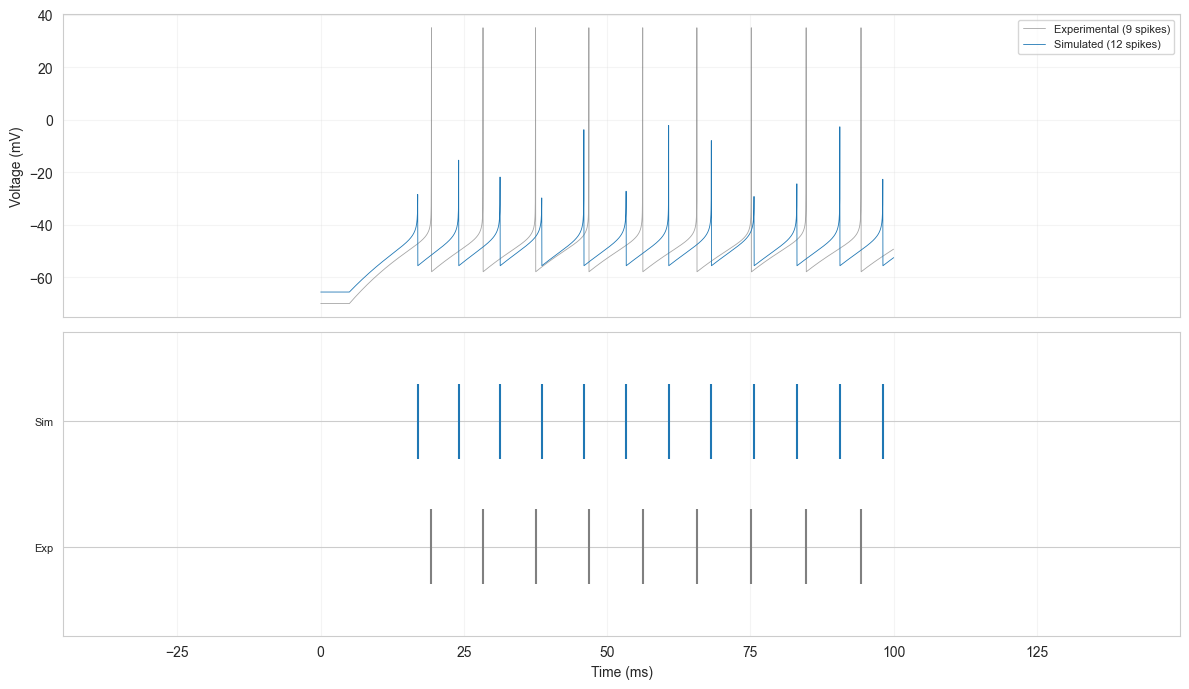

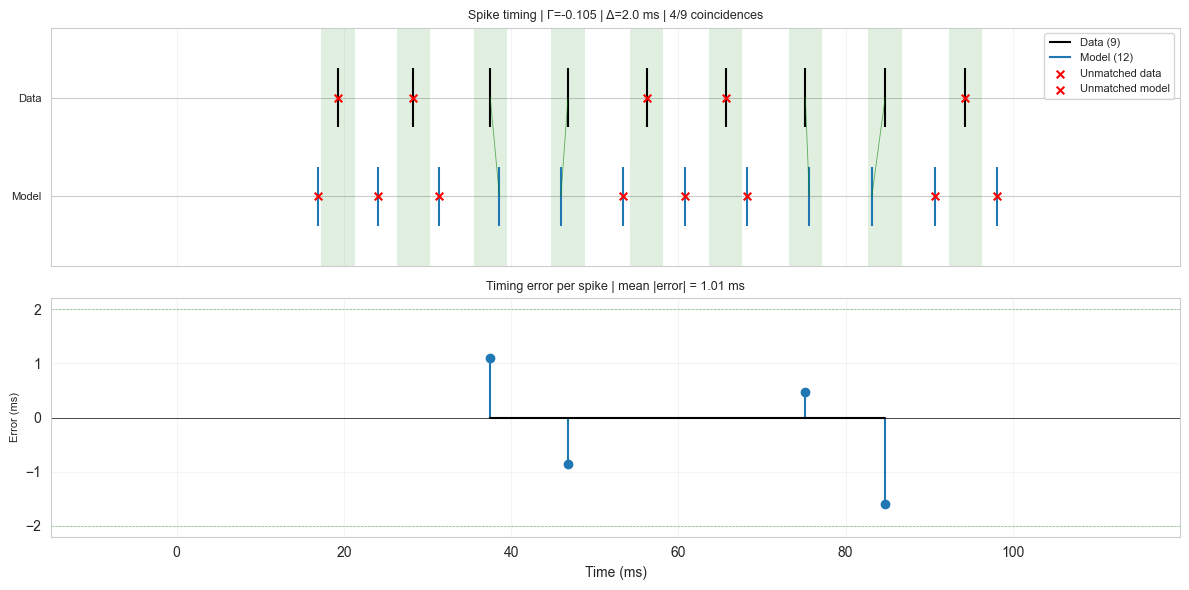

In [6]:
# Simulate with perturbed initial parameters to see the starting point
sim_init = simulate_with_current_trace(
    params=initial_params,
    # params=ground_truth_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Initial simulation: {sim_init.n_spikes} spikes (target: {data.n_spikes})")


if sim_init.n_spikes > 0 and data.n_spikes > 0:
    cf_s0 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_init.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s0.gamma:.3f}")
else:
    cf_s1 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_init);

if cf_s0 is not None:
    spike_timing_plot(data, sim_init, cf_s0);


In [7]:
# --- Establish loss floors: evaluate losses at ground truth parameters ---
# The soft feature extraction (used during training) won't exactly match the hard
# feature extraction (used for targets), creating an irreducible baseline loss.

# -- Stage 1 floor (Guarino) --
_config_gt = TrainingConfig(
    surrogate_type="superspike", surrogate_slope=2.0, clip_to_bounds=True,
)
_cell_gt1, _stim_gt1, _tmax_gt1, _params_gt1 = setup_trainable_cell(
    initial_params=ground_truth_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    config=_config_gt,
    trainable_params=TRAINABLE_STAGE1,
)
_exp_features = extract_experimental_features(
    voltage_trace=data.voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
)
_loss_fn_gt1 = make_guarino_loss_fn(
    cell=_cell_gt1, data_stimuli=_stim_gt1, t_max=_tmax_gt1, dt_ms=data.dt_ms,
    exp_features=_exp_features, stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    loss_config=GuarinoLossConfig(),
)
loss_floor_s1 = float(_loss_fn_gt1(_params_gt1))

print(f"Loss floor (Guarino  at ground truth): {loss_floor_s1:.4f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Loss floor (Guarino  at ground truth): 0.0209


## 4. Stage 1 — Guarino Loss (Coarse Feature Matching)

In [8]:
# Convert current trace to nA (Jaxley units, scaled by C_m)
exp_voltage = jnp.array(data.voltage)

# --- Stage 1 config ---
training_config = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.01,
    n_epochs=50,
    surrogate_type="superspike",
    surrogate_slope=10.0,
    print_every=1,
    polyak_alpha=1.0,
    polyak_beta=0.8,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
)

# Create trainable cell
cell1, data_stimuli1, t_max1, trainable_params1 = setup_trainable_cell(
    initial_params=initial_params,
    # initial_params=ground_truth_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    config=training_config,
    trainable_params=TRAINABLE_STAGE1,
)

# Extract target features for Guarino loss
exp_features = extract_experimental_features(
    voltage_trace=exp_voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
)

loss_fn_stage1 = make_guarino_loss_fn(
    cell=cell1,
    data_stimuli=data_stimuli1,
    t_max=t_max1,
    dt_ms=data.dt_ms,
    exp_features=exp_features,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    loss_config=GuarinoLossConfig(
        weight_spike_count=0.1,
    ),
    #loss_config=GuarinoLossConfig(),
    temperature=0.2,
    beta=10,
    validity_beta=10
)

print(f"Initial Guarino loss: {float(loss_fn_stage1(trainable_params1)):.4f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Initial Guarino loss: 2.3114


In [9]:
result_stage1 = train(
    loss_fn=loss_fn_stage1,
    trainable_params=trainable_params1,
    config=training_config,
    initial_params=initial_params,
)

print(f"\nStage 1 complete.")
print(f"  Best loss:   {result_stage1.best_loss:.4f}")
print(f"  Total time:  {result_stage1.total_time:.1f} s")

Training: optimizer=polyak lr=0.01 epochs=50 surrogate=superspike slope=10.0 alpha=1.0 beta=0.8 sigmoid_transform
Epoch    0 | loss=2.311440 | grad_norm=4.62e+04 | lr=2.31e-02 | C_m=220.6782, g_L=9.6353, v_reset=-54.6356, v_T=-51.5897, E_L=-65.6110, delta_T=2.1765
Epoch    1 | loss=4.737000 | grad_norm=3.00e+05 | lr=4.74e-02 | C_m=222.8019, g_L=9.6967, v_reset=-54.6723, v_T=-48.3740, E_L=-65.6286, delta_T=2.4159
Epoch    2 | loss=0.250308 | grad_norm=1.73e+01 | lr=2.50e-03 | C_m=222.7955, g_L=9.6962, v_reset=-54.6542, v_T=-48.3949, E_L=-65.6285, delta_T=2.4143
Epoch    3 | loss=0.284422 | grad_norm=6.19e+02 | lr=2.84e-03 | C_m=222.8104, g_L=9.6973, v_reset=-54.6966, v_T=-48.3465, E_L=-65.6286, delta_T=2.4179
Epoch    4 | loss=0.219761 | grad_norm=1.61e+03 | lr=2.20e-03 | C_m=222.8153, g_L=9.6978, v_reset=-54.7511, v_T=-48.3132, E_L=-65.6287, delta_T=2.4204
Epoch    5 | loss=0.164463 | grad_norm=4.18e+03 | lr=1.64e-03 | C_m=222.8297, g_L=9.6988, v_reset=-54.7847, v_T=-48.2709, E_L=-65.6


Stage 1 complete.
  Best loss:   0.0756
  Total time:  0.9 s


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 1: 9 spikes (target: 9)
Gamma = 1.000


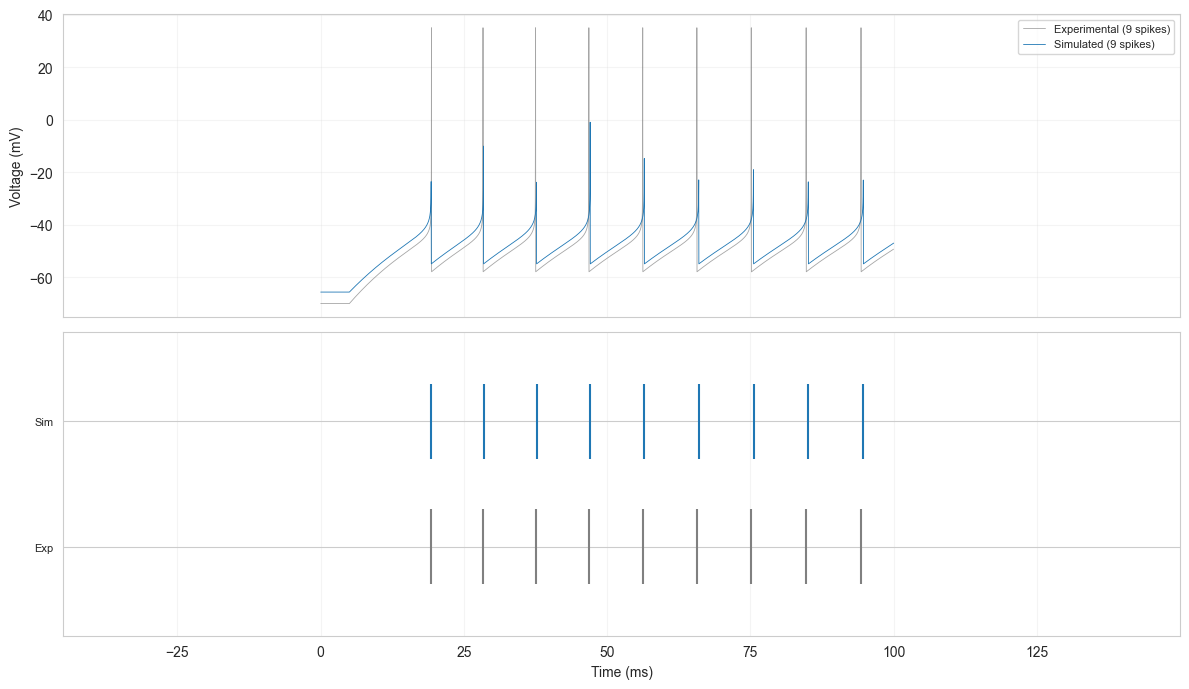

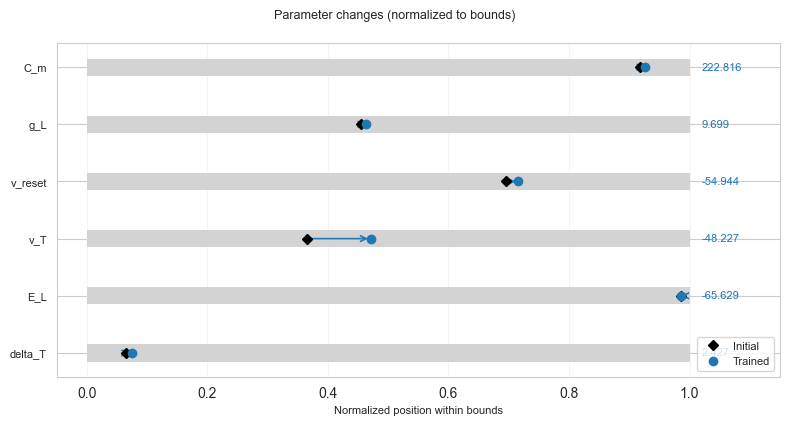

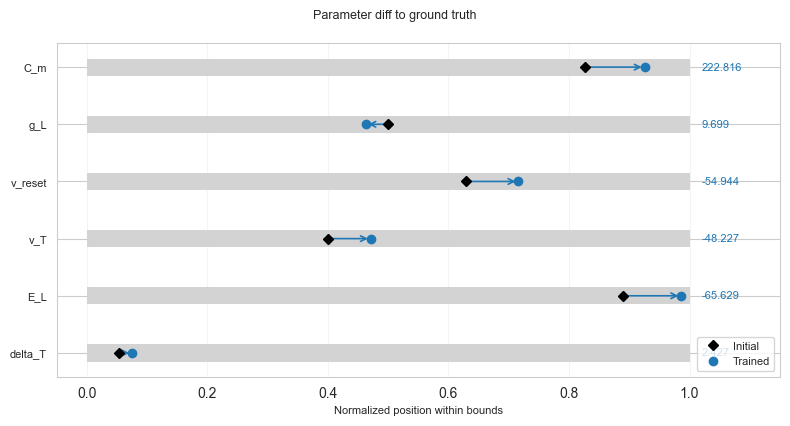

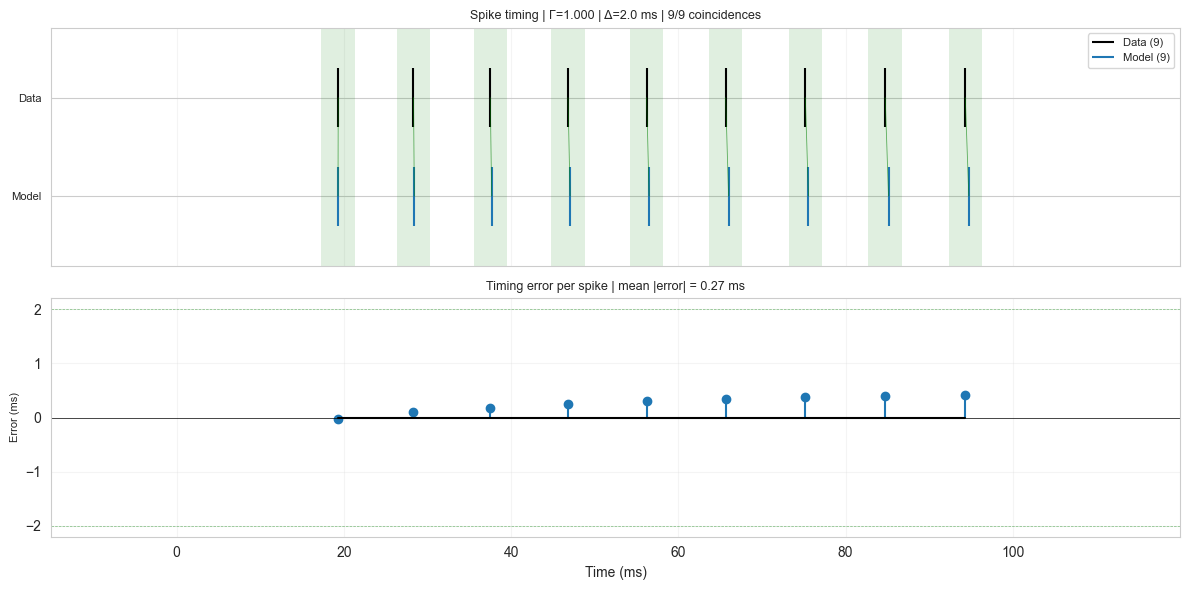

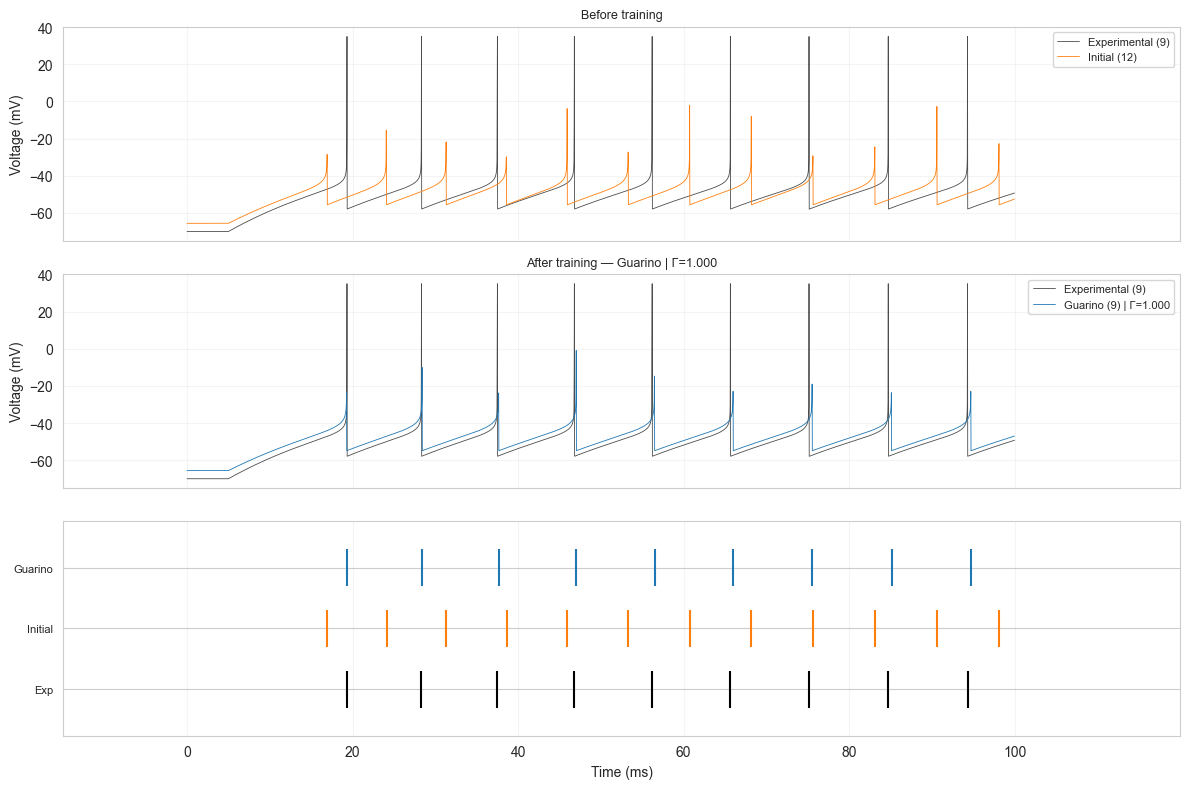

In [10]:
# Evaluate stage 1
params_after_s1 = dict(initial_params)
params_after_s1.update(result_stage1.get_params_dict())

sim_stage1 = simulate_with_current_trace(
    params=params_after_s1,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Stage 1: {sim_stage1.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage1.n_spikes > 0 and data.n_spikes > 0:
    cf_s1 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage1.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s1.gamma:.3f}")
else:
    cf_s1 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage1)
parameter_comparison_plot(result_stage1);
parameter_comparison_plot(TrainingResult(
    trainable_params=result_stage1.trainable_params,
    loss_history=result_stage1.loss_history,
    time_per_epoch=result_stage1.time_per_epoch,
    config=result_stage1.config,
    initial_params=ground_truth_params), figtitle="Parameter diff to ground truth");

if cf_s1 is not None:
    spike_timing_plot(data, sim_stage1, cf_s1);


fit_before_after_plot(
    data,
    sim_init,
    [sim_stage1],
    coincidence=[cf_s1],
    labels=["Guarino"],
);

## 5. Publication Figure — Synthetic Recovery Summary

Single composite figure suitable for the thesis: voltage-trace overlay (ground truth
vs. perturbed init vs. recovered), spike raster, training-loss curve, and per-parameter
recovery error. Saved as PDF at thesis-print proportions with serif fonts.

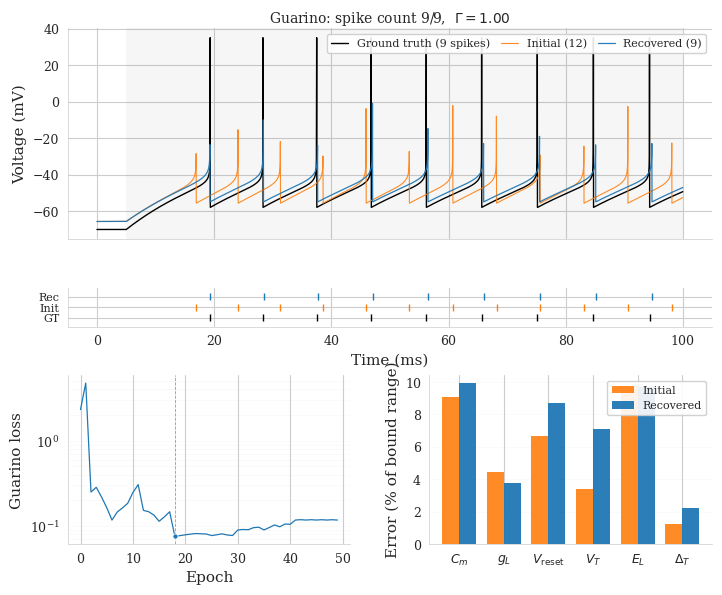

Saved guarino_synthetic_recovery.pdf


In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Figure config ---------------------------------------------------------
LOSS_NAME = "Guarino"
OUTPUT_PDF = f"{LOSS_NAME.lower()}_synthetic_recovery.pdf"

GT_COLOR = "k"
INIT_COLOR = "tab:orange"
TRAINED_COLOR = "tab:blue"

PARAM_LABELS_TEX = {
    "C_m": r"$C_m$", "g_L": r"$g_L$", "E_L": r"$E_L$", "v_T": r"$V_T$",
    "delta_T": r"$\Delta_T$", "v_reset": r"$V_\mathrm{reset}$",
    "v_threshold": r"$V_\mathrm{th}$", "tau_w": r"$\tau_w$",
    "a": r"$a$", "b": r"$b$",
}

# --- Compute per-parameter recovery error (% of bound range) ---------------
trainable = list(TRAINABLE_STAGE1)
init_err = []
final_err = []
for k in trainable:
    gt = ground_truth_params[k]
    bd = PARAM_BOUNDS[k]
    rng = bd.max - bd.min
    init_err.append(abs(initial_params[k] - gt) / rng * 100)
    final_err.append(abs(params_after_s1[k] - gt) / rng * 100)

# --- Build figure -----------------------------------------------------------
with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.6,
    "lines.linewidth": 0.9,
}):
    fig = plt.figure(figsize=(7.2, 6.0))
    gs = gridspec.GridSpec(
        3, 2,
        height_ratios=[3.0, 0.55, 2.4],
        hspace=0.35, wspace=0.28,
        left=0.09, right=0.985, top=0.95, bottom=0.09,
    )
    ax_v = fig.add_subplot(gs[0, :])
    ax_r = fig.add_subplot(gs[1, :], sharex=ax_v)
    ax_loss = fig.add_subplot(gs[2, 0])
    ax_p = fig.add_subplot(gs[2, 1])

    n = min(len(data.time), len(sim_init.time), len(sim_stage1.time))
    t = data.time[:n]

    # (a) Voltage traces
    t_stim_start = data.time[data.stim_start_idx]
    t_stim_end = data.time[min(data.stim_end_idx, n - 1)]
    ax_v.axvspan(t_stim_start, t_stim_end, color="grey", alpha=0.07, lw=0)

    ax_v.plot(t, data.voltage[:n], color=GT_COLOR, lw=1.0,
              label=f"Ground truth ({data.n_spikes} spikes)")
    ax_v.plot(t, sim_init.voltage[:n], color=INIT_COLOR, lw=0.8, alpha=0.9,
              label=f"Initial ({sim_init.n_spikes})")
    ax_v.plot(t, sim_stage1.voltage[:n], color=TRAINED_COLOR, lw=0.9, alpha=0.95,
              label=f"Recovered ({sim_stage1.n_spikes})")
    ax_v.set_ylabel("Voltage (mV)")
    ax_v.legend(loc="upper right", framealpha=0.9, ncol=3, fontsize=8,
                handlelength=1.5, columnspacing=1.0)
    if cf_s1 is not None:
        title = (rf"{LOSS_NAME}: spike count {sim_stage1.n_spikes}/{data.n_spikes},  "
                 rf"$\Gamma = {cf_s1.gamma:.2f}$")
    else:
        title = rf"{LOSS_NAME}: spike count {sim_stage1.n_spikes}/{data.n_spikes}"
    ax_v.set_title(title, fontsize=10, pad=4)
    ax_v.tick_params(direction="out", length=2.5, width=0.5)
    for sp in ax_v.spines.values():
        sp.set_linewidth(0.5)
    ax_v.spines["top"].set_visible(False)
    ax_v.spines["right"].set_visible(False)
    plt.setp(ax_v.get_xticklabels(), visible=False)

    # (b) Spike raster
    trains, raster_colors, raster_labels = [], [], []
    for st, color, lbl in [
        (data.spike_times, GT_COLOR, "GT"),
        (sim_init.spike_times, INIT_COLOR, "Init"),
        (sim_stage1.spike_times, TRAINED_COLOR, "Rec"),
    ]:
        if len(st) > 0:
            trains.append(st); raster_colors.append(color); raster_labels.append(lbl)
    if trains:
        ax_r.eventplot(trains, colors=raster_colors, linelengths=0.7, linewidths=1.0)
        ax_r.set_yticks(range(len(raster_labels)))
        ax_r.set_yticklabels(raster_labels, fontsize=8)
    ax_r.set_xlabel("Time (ms)")
    ax_r.tick_params(direction="out", length=2.5, width=0.5)
    for sp in ax_r.spines.values():
        sp.set_linewidth(0.5)
    ax_r.spines["top"].set_visible(False)
    ax_r.spines["right"].set_visible(False)

    # (c) Loss history
    history = np.asarray(result_stage1.loss_history)
    epochs = np.arange(len(history))
    ax_loss.semilogy(epochs, history, color=TRAINED_COLOR, lw=0.9)
    best_epoch = getattr(result_stage1, "best_epoch", None)
    if best_epoch is not None:
        ax_loss.axvline(best_epoch, ls="--", color="grey", lw=0.6, alpha=0.8)
        ax_loss.scatter(
            [best_epoch], [history[best_epoch]],
            color=TRAINED_COLOR, s=14, zorder=3,
            edgecolor="white", linewidth=0.6,
        )
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel(f"{LOSS_NAME} loss")
    ax_loss.tick_params(direction="out", length=2.5, width=0.5)
    for sp in ax_loss.spines.values():
        sp.set_linewidth(0.5)
    ax_loss.spines["top"].set_visible(False)
    ax_loss.spines["right"].set_visible(False)
    ax_loss.grid(True, which="both", axis="y", alpha=0.15, lw=0.4)

    # (d) Parameter recovery
    x = np.arange(len(trainable))
    bw = 0.38
    ax_p.bar(x - bw / 2, init_err, bw, color=INIT_COLOR, alpha=0.9,
             label="Initial", linewidth=0)
    ax_p.bar(x + bw / 2, final_err, bw, color=TRAINED_COLOR, alpha=0.95,
             label="Recovered", linewidth=0)
    ax_p.set_xticks(x)
    ax_p.set_xticklabels([PARAM_LABELS_TEX.get(k, k) for k in trainable])
    ax_p.set_ylabel("Error (% of bound range)")
    ax_p.legend(framealpha=0.9, fontsize=8, loc="upper right")
    ax_p.tick_params(direction="out", length=2.5, width=0.5)
    for sp in ax_p.spines.values():
        sp.set_linewidth(0.5)
    ax_p.spines["top"].set_visible(False)
    ax_p.spines["right"].set_visible(False)
    ax_p.grid(True, axis="y", alpha=0.15, lw=0.4)

    fig.savefig(OUTPUT_PDF, bbox_inches="tight")
    plt.show()
    print(f"Saved {OUTPUT_PDF}")